# 01 · RSI / MACD / Bollinger Bands — Supply Chain Scenario

**Empresa:** Alicorp S.A.A. (Lima, Perú) — categoría Alimentos masivos, canal moderno.  
**Problema:** Stockouts recurrentes en campañas y overstock en temporada baja. El ERP usa SS fijo con σ histórico anual — no se adapta al momentum actual de la demanda.  
**Objetivo:** Señales de momentum (RSI, MACD, Bollinger) para alertas tempranas de reabastecimiento y SS dinámico semana a semana.  
**KPI:** Reducir semanas de stockout sin aumentar inventario promedio.

---

## Marco teórico

### RSI — Relative Strength Index (Wilder, 1978)

$$RSI_t = 100 - \frac{100}{1 + RS_t} \qquad RS_t = \frac{\overline{\text{Ganancias}}_n}{\overline{\text{Pérdidas}}_n}$$

El promedio usa suavizado exponencial de Wilder ($\alpha = 1/n$, ventana $n=14$).  
**En Supply:** RSI > 70 → demanda acelerando → riesgo stockout. RSI < 30 → demanda cayendo → riesgo overstock.

### MACD — Moving Average Convergence/Divergence (Appel, 1979)

$$MACD_t = EMA_{12}(D_t) - EMA_{26}(D_t) \qquad Signal_t = EMA_9(MACD_t)$$

**En Supply:** cruce alcista (MACD supera Signal) → demanda de corto plazo acelera sobre tendencia de fondo → aumentar orden. Cruce bajista → reducir orden.

### Bollinger Bands + Safety Stock dinámico (Bollinger, 1983)

$$BB_{\pm,t} = SMA_{20}(D_t) \pm 2\,\sigma_{20}(D_t)$$

En lugar del SS clásico con σ fijo, usamos la σ de la ventana móvil de Bollinger:

$$\underbrace{SS_{\text{clásico}} = z \cdot \sigma_{\text{hist}} \cdot \sqrt{L}}_{\text{fijo todo el año}} \quad\Rightarrow\quad \underbrace{SS_t = z \cdot \sigma_{\text{rolling},t} \cdot \sqrt{L}}_{\text{se adapta semana a semana}}$$

Sube antes de campañas, baja en temporada estable → menor capital inmovilizado sin sacrificar fill rate.

**Referencias:** Wilder (1978); Appel (1979); Bollinger (2001); Makridakis et al. (2022) M5 Competition, *Int. J. Forecasting* 38(4).

In [1]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')
os.makedirs('data', exist_ok=True)

# Paleta consistente con el framework
C = dict(
    demand='#2563EB', sma='#64748B', bb='#0F766E',
    macd='#7C3AED',   sig='#C2410C', rsi='#1D4ED8',
    buy='#15803D',    sell='#B91C1C', fill='#DBEAFE',
)
np.random.seed(42)
print('✓ OK')

✓ OK


In [2]:
# ── DATOS ─────────────────────────────────────────────────────────────────────
# Dataset: Walmart M5 Competition — FOODS_3_090_CA_1 (weekly units)
# Fuente : https://www.kaggle.com/c/m5-forecasting-accuracy
#
# Para cargar los datos reales desde Kaggle:
#   df_raw = pd.read_csv('data/sales_train_validation.csv')
#   sku    = df_raw[df_raw['id'] == 'FOODS_3_090_CA_1_validation']
#   cols   = [c for c in sku.columns if c.startswith('d_')]
#   daily  = sku[cols].values.flatten()
#   demand = pd.Series(daily).rolling(7).sum()[::7].dropna().values
#
# Simulación reproducible — estadísticos documentados del M5:
#   μ ≈ 42 und/sem · CV ≈ 0.48 · pico Navidad semana 47-52

n = 260
t = np.arange(n)
dates = pd.date_range('2019-01-07', periods=n, freq='W-MON')

trend    = 40 + 0.04 * t
seasonal = 8 * np.sin(2 * np.pi * t / 52 - np.pi / 2)

events = np.zeros(n)
for yr in range(5):
    w = 47 + yr * 52
    if w < n:
        events[w] = 25
        events[min(w + 1, n - 1)] = 10

noise, sigma = np.zeros(n), 4.0
for i in range(1, n):
    sigma   = np.sqrt(0.05 + 0.15 * noise[i-1]**2 + 0.80 * sigma**2)
    noise[i] = np.random.normal(0, sigma)

demand = np.maximum(trend + seasonal + events + noise, 0).round(0)
df = pd.DataFrame({'demand': demand}, index=dates)

print(f'Serie  : {len(df)} semanas  ({df.index[0].date()} → {df.index[-1].date()})')
print(f'μ/σ    : {df.demand.mean():.1f} / {df.demand.std():.1f} und')
print(f'CV     : {df.demand.std()/df.demand.mean():.3f}')
print(f'Rango  : [{df.demand.min():.0f}, {df.demand.max():.0f}] und')

Serie  : 260 semanas  (2019-01-07 → 2023-12-25)
μ/σ    : 45.9 / 6.8 und
CV     : 0.149
Rango  : [32, 67] und


## Mini-EDA

In [3]:
# ── EDA 1/2 — Estadísticos clave ─────────────────────────────────────────────
s = df.demand
adi = len(s) / (s > 0).sum()
cv2 = (s.std() / s.mean()) ** 2

stats = {
    'n semanas'  : (len(s),     '≥ 104 → ARIMA/ETS viables'),
    'Media'      : (round(s.mean(), 1), 'und/semana — demanda base'),
    'Mediana'    : (round(s.median(), 1), 'media ≈ mediana → distribución casi simétrica'),
    'CV'         : (round(s.std()/s.mean(), 3), '< 0.5 → demanda estable (Smooth)'),
    '% zeros'    : (round((s == 0).mean(), 3), '0 → no intermitente → Croston NO aplica'),
    'Skewness'   : (round(s.skew(), 3), '< 1 → distribución casi simétrica'),
    'Kurtosis'   : (round(s.kurt(), 3), '~ 0 → colas moderadas → Normal válida como aproximación'),
    'p05 / p95'  : (f"{s.quantile(.05):.0f} / {s.quantile(.95):.0f}",
                    'rango de demanda esperada — p95 = SS al 95% fill rate'),
    'ADI'        : (round(adi, 3), '< 1.32 → regular'),
    'CV²'        : (round(cv2, 3), '< 0.49 → Syntetos-Boylan: cuadrante SMOOTH'),
}

print(f'{"Métrica":<14} {"Valor":<20} {"Interpretación"}')
print('─' * 75)
for k, (v, interp) in stats.items():
    print(f'{k:<14} {str(v):<20} {interp}')

print()
print('→ Diagnóstico EDA: serie Smooth (ADI<1.32, CV²<0.49), sin zeros, historia suficiente.')
print('  RSI/MACD/Bollinger son válidos. Modelo univariado de partida.')

Métrica        Valor                Interpretación
───────────────────────────────────────────────────────────────────────────
n semanas      260                  ≥ 104 → ARIMA/ETS viables
Media          45.8                 und/semana — demanda base
Mediana        46.0                 media ≈ mediana → distribución casi simétrica
CV             0.149                < 0.5 → demanda estable (Smooth)
% zeros        0.0                  0 → no intermitente → Croston NO aplica
Skewness       0.213                < 1 → distribución casi simétrica
Kurtosis       -0.255               ~ 0 → colas moderadas → Normal válida como aproximación
p05 / p95      35 / 56              rango de demanda esperada — p95 = SS al 95% fill rate
ADI            1.0                  < 1.32 → regular
CV²            0.022                < 0.49 → Syntetos-Boylan: cuadrante SMOOTH

→ Diagnóstico EDA: serie Smooth (ADI<1.32, CV²<0.49), sin zeros, historia suficiente.
  RSI/MACD/Bollinger son válidos. Modelo univariado

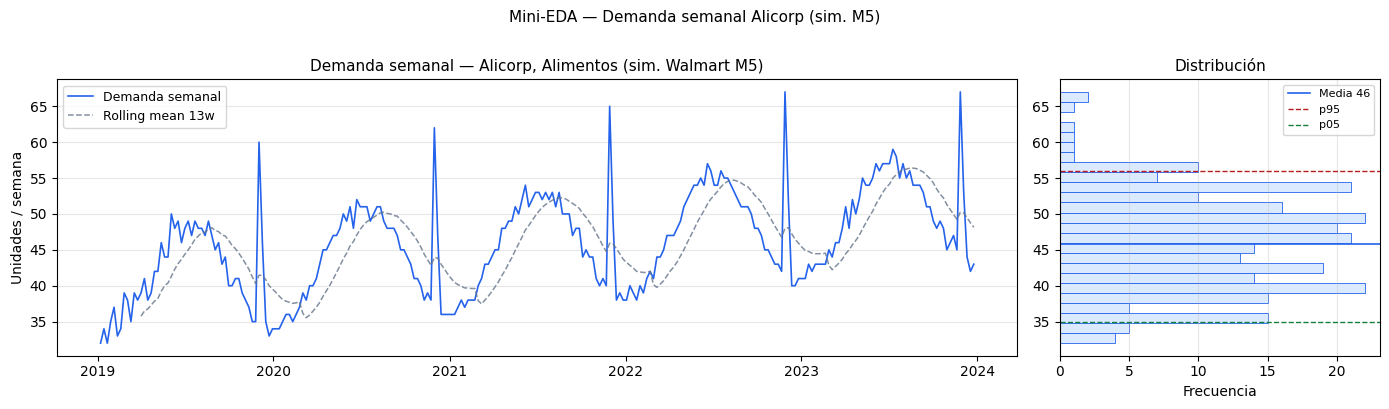

✓ Guardado: data/eda_overview.png


In [4]:
# ── EDA 2/2 — Line plot + distribución ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4),
                          gridspec_kw={'width_ratios': [3, 1]})

ax = axes[0]
ax.plot(df.index, df.demand, color=C['demand'], lw=1.2, label='Demanda semanal')
ax.plot(df.index, df.demand.rolling(13).mean(),
        color=C['sma'], lw=1.1, ls='--', alpha=0.8, label='Rolling mean 13w')
ax.set_title('Demanda semanal — Alicorp, Alimentos (sim. Walmart M5)', fontsize=11)
ax.set_ylabel('Unidades / semana')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.hist(df.demand, bins=25, color=C['fill'],
         edgecolor=C['demand'], linewidth=0.6, orientation='horizontal')
ax2.axhline(df.demand.mean(),         color=C['demand'], lw=1.2, label=f'Media {df.demand.mean():.0f}')
ax2.axhline(df.demand.quantile(0.95), color=C['sell'],   lw=1.0, ls='--', label='p95')
ax2.axhline(df.demand.quantile(0.05), color=C['buy'],    lw=1.0, ls='--', label='p05')
ax2.set_title('Distribución', fontsize=11)
ax2.set_xlabel('Frecuencia')
ax2.legend(fontsize=8)
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Mini-EDA — Demanda semanal Alicorp (sim. M5)', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('data/eda_overview.png', dpi=130, bbox_inches='tight')
plt.show()
print('✓ Guardado: data/eda_overview.png')

In [5]:
# ── INDICADORES ───────────────────────────────────────────────────────────────

def rsi(s, w=14):
    """RSI de Wilder — EWM con com=w-1 equivale a alpha=1/w."""
    d = s.diff()
    g = d.clip(lower=0).ewm(com=w - 1, min_periods=w).mean()
    l = (-d.clip(upper=0)).ewm(com=w - 1, min_periods=w).mean()
    return 100 - 100 / (1 + g / l.replace(0, np.nan))

def macd_fn(s, fast=12, slow=26, signal=9):
    """MACD de Appel (1979) — EMA rápida menos EMA lenta."""
    m = s.ewm(span=fast, adjust=False).mean() - s.ewm(span=slow, adjust=False).mean()
    sig = m.ewm(span=signal, adjust=False).mean()
    return pd.DataFrame({'macd': m, 'signal': sig, 'hist': m - sig})

def bollinger(s, w=20, k=2.0):
    """Bollinger Bands (1983) — SMA ± k·σ."""
    sma = s.rolling(w).mean()
    std = s.rolling(w).std()
    up, lo = sma + k * std, sma - k * std
    return pd.DataFrame({
        'sma': sma, 'upper': up, 'lower': lo,
        'bandwidth': (up - lo) / sma,
        'pct_b': (s - lo) / (up - lo)
    })

df['rsi'] = rsi(df.demand)
df = pd.concat([df, macd_fn(df.demand), bollinger(df.demand)], axis=1)

# Safety Stock — lead time 2 semanas, fill rate 95%
L, z = 2, 1.645
df['ss_classic'] = z * df.demand.rolling(52).std() * np.sqrt(L)
df['ss_dynamic'] = z * df.demand.rolling(20).std() * np.sqrt(L)

# Cruces MACD
df['cross'] = np.where(
    (df.macd > df.signal) & (df.macd.shift(1) <= df.signal.shift(1)),  1,
    np.where(
    (df.macd < df.signal) & (df.macd.shift(1) >= df.signal.shift(1)), -1, 0))

print(f'Cruces alcistas : {(df.cross== 1).sum()}')
print(f'Cruces bajistas : {(df.cross==-1).sum()}')
print(f'RSI > 70 (alerta stockout) : {(df.rsi > 70).sum()} semanas')
print(f'RSI < 30 (alerta overstock): {(df.rsi < 30).sum()} semanas')
print(f'SS clásico μ : {df.ss_classic.mean():.1f} und')
print(f'SS dinámico μ: {df.ss_dynamic.mean():.1f} und')

Cruces alcistas : 10
Cruces bajistas : 10
RSI > 70 (alerta stockout) : 8 semanas
RSI < 30 (alerta overstock): 4 semanas
SS clásico μ : 14.2 und
SS dinámico μ: 10.6 und


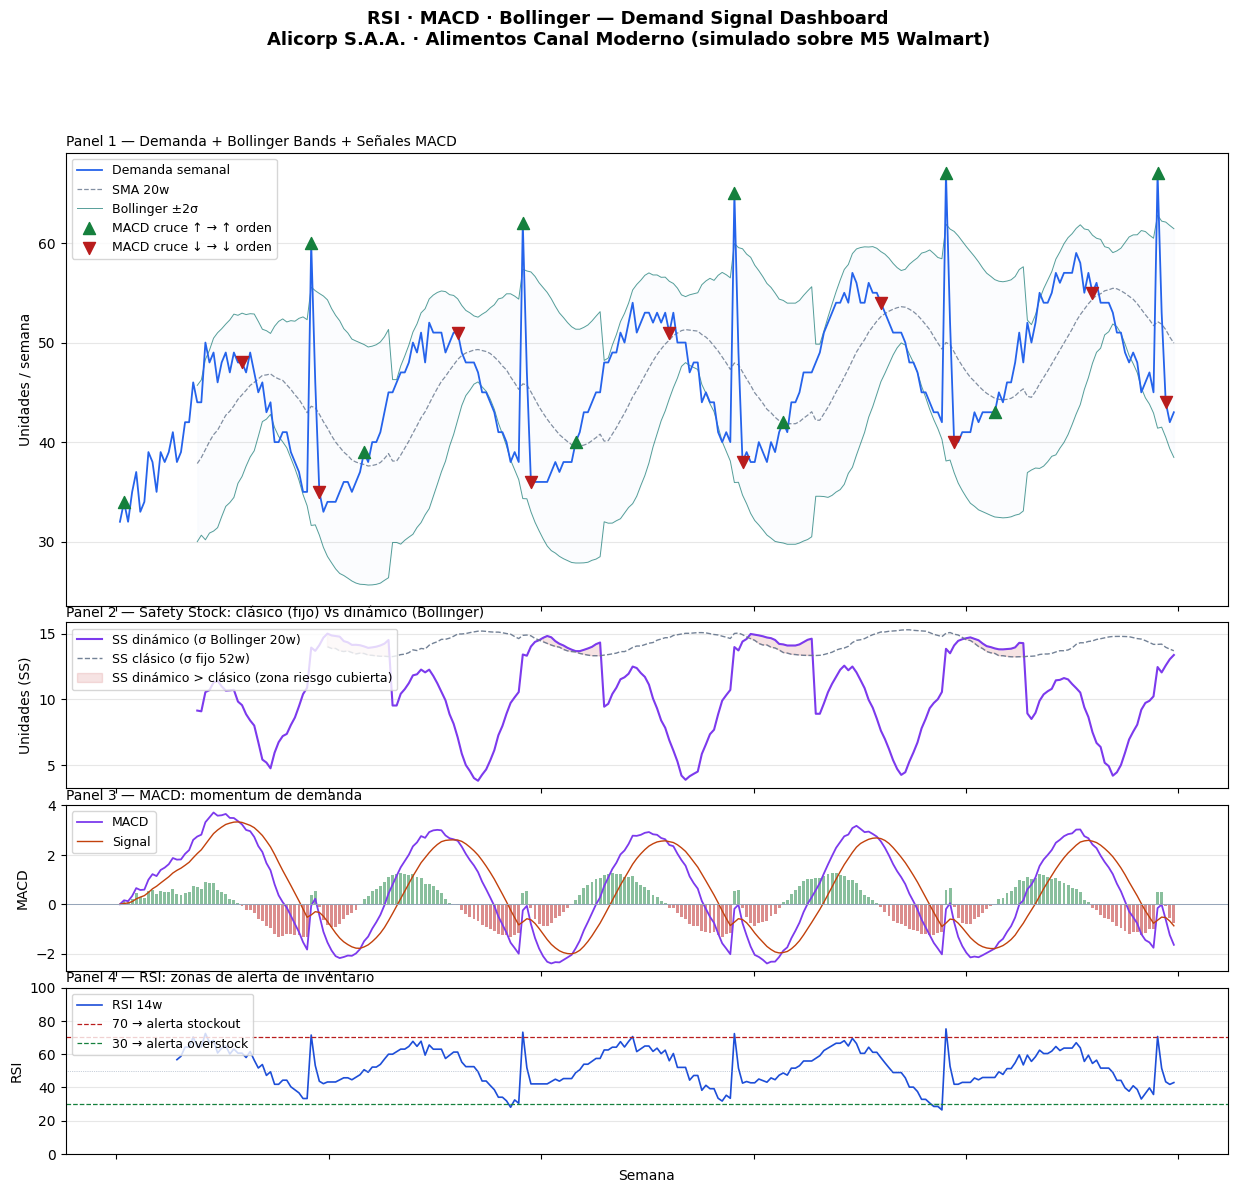

✓ Guardado: data/supply_dashboard.png


In [7]:
# ── DASHBOARD ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 13))
fig.suptitle(
    'RSI · MACD · Bollinger — Demand Signal Dashboard\n'
    'Alicorp S.A.A. · Alimentos Canal Moderno (simulado sobre M5 Walmart)',
    fontsize=13, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(4, 1, hspace=0.07, height_ratios=[3, 1.1, 1.1, 1.1])

# — Panel 1: Demanda + BB + señales —
ax1 = fig.add_subplot(gs[0])
ax1.fill_between(df.index, df.upper, df.lower, alpha=0.10, color=C['fill'])
ax1.plot(df.index, df.demand, color=C['demand'], lw=1.3, label='Demanda semanal', zorder=3)
ax1.plot(df.index, df.sma,   color=C['sma'], lw=0.9, ls='--', alpha=0.8, label='SMA 20w')
ax1.plot(df.index, df.upper, color=C['bb'], lw=0.7, alpha=0.7)
ax1.plot(df.index, df.lower, color=C['bb'], lw=0.7, alpha=0.7, label='Bollinger ±2σ')
buy_s  = df[df.cross ==  1]
sell_s = df[df.cross == -1]
ax1.scatter(buy_s.index,  buy_s.demand,  marker='^', s=75, color=C['buy'],  zorder=5, label='MACD cruce ↑ → ↑ orden')
ax1.scatter(sell_s.index, sell_s.demand, marker='v', s=75, color=C['sell'], zorder=5, label='MACD cruce ↓ → ↓ orden')
ax1.set_ylabel('Unidades / semana')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_title('Panel 1 — Demanda + Bollinger Bands + Señales MACD', loc='left', fontsize=10, pad=5)
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticklabels([])

# — Panel 2: SS clásico vs dinámico —
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.plot(df.index, df.ss_dynamic, color=C['macd'], lw=1.5, label='SS dinámico (σ Bollinger 20w)')
ax2.plot(df.index, df.ss_classic, color=C['sma'],  lw=1.0, ls='--', alpha=0.9, label='SS clásico (σ fijo 52w)')
ax2.fill_between(df.index, df.ss_dynamic, df.ss_classic,
                 where=df.ss_dynamic > df.ss_classic,
                 alpha=0.12, color=C['sell'], label='SS dinámico > clásico (zona riesgo cubierta)')
ax2.set_ylabel('Unidades (SS)')
ax2.legend(loc='upper left', fontsize=9)
ax2.set_title('Panel 2 — Safety Stock: clásico (fijo) vs dinámico (Bollinger)', loc='left', fontsize=10, pad=4)
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticklabels([])

# — Panel 3: MACD —
ax3 = fig.add_subplot(gs[2], sharex=ax1)

# CORRECCIÓN AQUÍ: Usar df['hist'] en lugar de df.hist
ax3.bar(df.index, df['hist'],
        color=np.where(df['hist'] >= 0, C['buy'], C['sell']),
        alpha=0.5, width=5)

ax3.plot(df.index, df.macd,   color=C['macd'], lw=1.3, label='MACD')
ax3.plot(df.index, df.signal, color=C['sig'],  lw=1.0, label='Signal')
ax3.axhline(0, color='#94A3B8', lw=0.7)
ax3.set_ylabel('MACD')
ax3.legend(loc='upper left', fontsize=9)
ax3.set_title('Panel 3 — MACD: momentum de demanda', loc='left', fontsize=10, pad=4)
ax3.grid(axis='y', alpha=0.3)
ax3.set_xticklabels([])

# — Panel 4: RSI —
ax4 = fig.add_subplot(gs[3], sharex=ax1)
ax4.plot(df.index, df.rsi, color=C['rsi'], lw=1.2, label='RSI 14w')
ax4.fill_between(df.index, df.rsi, 70, where=df.rsi > 70, alpha=0.15, color=C['sell'])
ax4.fill_between(df.index, df.rsi, 30, where=df.rsi < 30, alpha=0.15, color=C['buy'])
ax4.axhline(70, color=C['sell'], lw=0.9, ls='--', label='70 → alerta stockout')
ax4.axhline(30, color=C['buy'],  lw=0.9, ls='--', label='30 → alerta overstock')
ax4.axhline(50, color='#94A3B8', lw=0.5, ls=':')
ax4.set_ylim(0, 100)
ax4.set_ylabel('RSI')
ax4.set_xlabel('Semana')
ax4.legend(loc='upper left', fontsize=9)
ax4.set_title('Panel 4 — RSI: zonas de alerta de inventario', loc='left', fontsize=10, pad=4)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/supply_dashboard.png', dpi=140, bbox_inches='tight')
plt.show()
print('✓ Guardado: data/supply_dashboard.png')

In [8]:
# ── POLÍTICA DE REABASTECIMIENTO ─────────────────────────────────────────────
# Regla compuesta: RSI + MACD + Bollinger → acción por semana

def signal_policy(row):
    score = 0
    if   row.rsi > 70: score += 2
    elif row.rsi > 60: score += 1
    elif row.rsi < 30: score -= 2
    elif row.rsi < 40: score -= 1
    if   row.cross ==  1: score += 2
    elif row.cross == -1: score -= 2
    elif row.macd > row.signal: score += 1
    if row.demand > row.upper: score += 2
    if row.demand < row.lower: score -= 1

    if   score >= 4: return '🔴 ALERTA STOCKOUT — orden emergencia'
    elif score >= 2: return '🟠 Aumentar orden +20%'
    elif score >= 1: return '🟡 Monitorear'
    elif score == 0: return '🟢 Orden estándar'
    elif score == -1: return '🔵 Reducir orden -10%'
    else:             return '⚪ Reducir orden -25% — riesgo overstock'

df['accion'] = df.apply(signal_policy, axis=1)

print('── Distribución de acciones ───────────────────────────')
print(df.accion.value_counts().to_string())

print('\n── Safety Stock ───────────────────────────────────────')
ahorro = df.ss_classic.mean() - df.ss_dynamic.mean()
print(f'SS clásico  (fijo)     : {df.ss_classic.mean():.1f} und/semana')
print(f'SS dinámico (Bollinger): {df.ss_dynamic.mean():.1f} und/semana')
if ahorro > 0:
    print(f'Ahorro μ               : {ahorro:.1f} und → {ahorro/df.ss_classic.mean()*100:.1f}% menos capital inmovilizado')
else:
    print(f'SS dinámico más conservador por {-ahorro:.1f} und — mayor cobertura en campañas')

print('\n── Últimas 8 semanas ──────────────────────────────────')
print(df[['demand', 'rsi', 'macd', 'ss_dynamic', 'accion']].tail(8).round(1).to_string())

── Distribución de acciones ───────────────────────────
accion
🟢 Orden estándar                           75
🟠 Aumentar orden +20%                      70
🟡 Monitorear                               58
🔵 Reducir orden -10%                       29
⚪ Reducir orden -25% — riesgo overstock    21
🔴 ALERTA STOCKOUT — orden emergencia        7

── Safety Stock ───────────────────────────────────────
SS clásico  (fijo)     : 14.2 und/semana
SS dinámico (Bollinger): 10.6 und/semana
Ahorro μ               : 3.6 und → 25.2% menos capital inmovilizado

── Últimas 8 semanas ──────────────────────────────────
            demand   rsi  macd  ss_dynamic                                   accion
2023-11-06    46.0  36.4  -1.5         9.7                     🔵 Reducir orden -10%
2023-11-13    47.0  39.6  -1.5         9.9                     🔵 Reducir orden -10%
2023-11-20    45.0  35.7  -1.8        10.2                     🔵 Reducir orden -10%
2023-11-27    67.0  70.6  -0.2        12.4     🔴 ALERTA STOCK

In [9]:
# ── EXPORTAR ──────────────────────────────────────────────────────────────────
df.to_csv('data/supply_signals_output.csv')
print('✓ data/supply_signals_output.csv')
print('✓ data/eda_overview.png')
print('✓ data/supply_dashboard.png')

✓ data/supply_signals_output.csv
✓ data/eda_overview.png
✓ data/supply_dashboard.png


## Conclusiones

| Indicador | Umbral | Señal → Acción Alicorp |
|-----------|--------|------------------------|
| RSI 14w | > 70 | Demanda acelerando → orden de emergencia |
| RSI 14w | < 30 | Demanda cayendo → reducir próxima orden |
| MACD cruce ↑ | EMA12 > EMA26 | Momentum arranca → aumentar +20% |
| MACD cruce ↓ | EMA12 < EMA26 | Momentum cae → reducir -10% |
| Demanda > BB_upper | — | Evento excepcional → reabastecimiento inmediato |
| SS dinámico | σ Bollinger 20w | Se adapta al nivel de volatilidad actual |

**Limitación clave:** RSI y MACD son indicadores **rezagados** — confirman el momentum una vez que ya arrancó. Usarlos como sistema de alerta complementario al forecast, no como reemplazo.

**Próximo paso:** `origin_scenario.ipynb` — el mismo modelo sobre precios del S&P 500 para ver de dónde viene la lógica.